# PCA Variance Inference on IMU Data

Legacy sections have been removed. This notebook keeps only a modern, reproducible PCA workflow for `imu_data.csv`.

## 1. Set Up Environment and Dependencies

In [8]:
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

SEED = 42
np.random.seed(SEED)

DATA_PATH = Path("imu_data.csv")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 200)
print("Data path:", DATA_PATH)
print("Seed:", SEED)

Data path: imu_data.csv
Seed: 42


## 2. Load Configuration and Input Data

In [9]:
config = {
    "possible_targets": ["class", "label", "target", "y", "activity"],
    "variance_thresholds": [0.90, 0.95, 0.99],
    "test_size": 0.25,
}

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing input data: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (544763, 16)
Columns: ['time', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z', 'pos_x', 'pos_y', 'pos_z', 'roll', 'pitch', 'yaw']


,time,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,pos_x,pos_y,pos_z,roll,pitch,yaw
0,0.000000,0.121071,0.055025,0.140186,-0.011067,-0.010805,-0.008495,0.035449,-0.019849,-1.021133,0.000000,0.000000,15.000000,0.0,-0.000000,0.0
1,0.004167,-15.144494,-47.289830,-3.771333,-0.007818,0.180222,-0.003270,0.141953,-0.004071,-1.121631,-0.000264,-0.000820,14.999937,-0.0,0.000730,-0.0
2,0.008333,39.823060,3.440746,20.060178,0.013213,0.357566,0.011768,0.087345,0.048932,-1.062799,0.000167,-0.001579,15.000221,-0.0,0.002191,-0.0
3,0.012500,39.949818,3.611063,19.980213,-0.013400,0.519162,0.023758,0.040748,-0.040171,-1.058048,0.001291,-0.002278,15.000852,-0.0,0.004379,-0.0
4,0.016667,40.177507,3.582990,19.928157,0.008903,0.705467,-0.002821,0.007020,0.033722,-1.019964,0.003111,-0.002916,15.001830,-0.0,0.007293,-0.0


## 3. Validate and Clean Data

In [10]:
validation = {
    "rows": int(df.shape[0]),
    "cols": int(df.shape[1]),
    "null_count": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
}

target_col = next((c for c in config["possible_targets"] if c in df.columns), df.columns[-1])

clean_df = df.copy()
for c in clean_df.columns:
    if c != target_col:
        clean_df[c] = pd.to_numeric(clean_df[c], errors="coerce")

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

print("Validation summary:", validation)
print("Target column:", target_col)
clean_df.head()

Validation summary: {'rows': 544763, 'cols': 16, 'null_count': 0, 'duplicate_rows': 0}
Target column: yaw


,time,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,pos_x,pos_y,pos_z,roll,pitch,yaw
0,0.000000,0.121071,0.055025,0.140186,-0.011067,-0.010805,-0.008495,0.035449,-0.019849,-1.021133,0.000000,0.000000,15.000000,0.0,-0.000000,0.0
1,0.004167,-15.144494,-47.289830,-3.771333,-0.007818,0.180222,-0.003270,0.141953,-0.004071,-1.121631,-0.000264,-0.000820,14.999937,-0.0,0.000730,-0.0
2,0.008333,39.823060,3.440746,20.060178,0.013213,0.357566,0.011768,0.087345,0.048932,-1.062799,0.000167,-0.001579,15.000221,-0.0,0.002191,-0.0
3,0.012500,39.949818,3.611063,19.980213,-0.013400,0.519162,0.023758,0.040748,-0.040171,-1.058048,0.001291,-0.002278,15.000852,-0.0,0.004379,-0.0
4,0.016667,40.177507,3.582990,19.928157,0.008903,0.705467,-0.002821,0.007020,0.033722,-1.019964,0.003111,-0.002916,15.001830,-0.0,0.007293,-0.0


## 4. Implement Modern Processing Pipeline

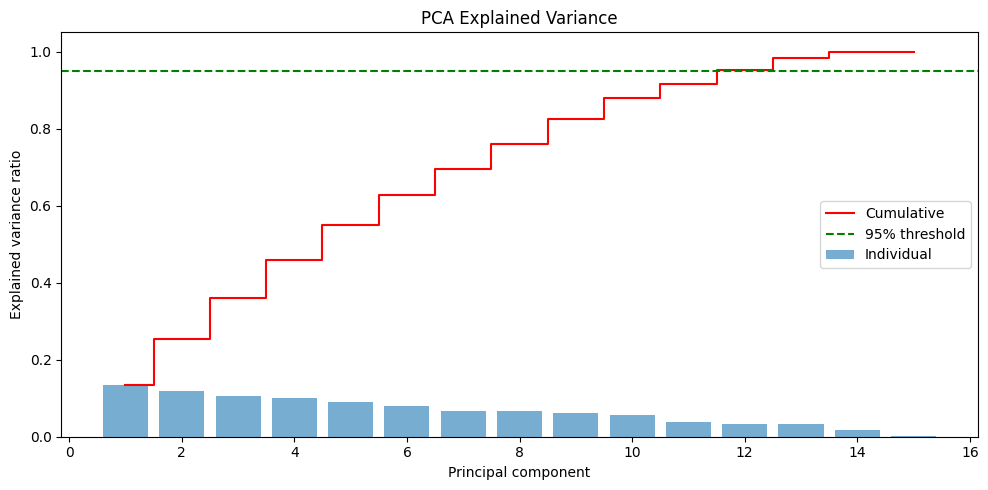

Components needed for 90% variance: 11 (retained=0.9171)
Components needed for 95% variance: 12 (retained=0.9510)
Components needed for 99% variance: 14 (retained=0.9994)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,yaw
0,0.157801,-0.121297,-0.560554,0.069068,-0.055522,-2.076405,-0.061379,-0.636972,0.203601,0.250371,-0.286804,0.056431,0.0
1,0.205439,-0.060043,0.705642,2.306259,-0.490284,-2.409030,-0.409049,-0.482101,-0.427127,0.016763,-1.116686,-2.347366,-0.0
2,0.284354,-0.200756,-4.073882,0.523357,0.373646,-1.860394,0.772333,-0.835593,0.911259,0.652470,3.024401,0.106083,-0.0
3,0.221117,-0.313147,-4.068209,0.507550,0.360579,-1.855987,0.765142,-0.823037,0.920762,0.653328,3.022530,0.115719,-0.0
4,0.179309,-0.214166,-4.071163,0.506709,0.355098,-1.816005,0.774338,-0.818490,0.921091,0.696528,3.022723,0.114046,-0.0


In [11]:
feature_df = clean_df.drop(columns=[target_col], errors="ignore")
feature_df = feature_df.select_dtypes(include=[np.number])

if feature_df.shape[1] == 0:
    raise ValueError("No numeric feature columns available for PCA.")

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(feature_df)
X_scaled = scaler.fit_transform(X_imputed)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained_ratio = pca_full.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_ratio) + 1), explained_ratio, alpha=0.6, label="Individual")
plt.step(range(1, len(cumulative_ratio) + 1), cumulative_ratio, where="mid", color="red", label="Cumulative")
plt.axhline(0.95, color="green", linestyle="--", label="95% threshold")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

for threshold in config["variance_thresholds"]:
    k = int(np.argmax(cumulative_ratio >= threshold) + 1)
    print(f"Components needed for {int(threshold*100)}% variance: {k} (retained={cumulative_ratio[k-1]:.4f})")

n_components_95 = int(np.argmax(cumulative_ratio >= 0.95) + 1)
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_95, columns=[f"PC{i}" for i in range(1, n_components_95 + 1)])
pca_df[target_col] = clean_df[target_col].values
pca_df.head()

## 5. Persist Artifacts and Reproducible Outputs

In [ ]:
pca_df.to_csv(ARTIFACT_DIR / "pca_reduced_data.csv", index=False)

run_metadata = {
    "timestamp_utc": datetime.utcnow().isoformat(),
    "input_path": str(DATA_PATH),
    "rows": int(clean_df.shape[0]),
    "original_feature_count": int(feature_df.shape[1]),
    "components_95": int(n_components_95),
    "variance_thresholds": config["variance_thresholds"],
}

with open(ARTIFACT_DIR / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

print("Saved:")
print("-", ARTIFACT_DIR / "pca_reduced_data.csv")
print("-", ARTIFACT_DIR / "run_metadata.json")
run_metadata